In [4]:
import pandas as pd
import numpy as np

In [5]:
from sklearn.datasets import fetch_california_housing

In [11]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [10]:
df = pd.DataFrame(fetch_california_housing().data,columns=fetch_california_housing().feature_names)

In [12]:
df['target'] = fetch_california_housing().target

In [13]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X=df.drop(columns=['target'])
y=df['target']

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [21]:
# Standardization of data
from sklearn.preprocessing import StandardScaler

In [22]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
X_train

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

In [25]:
# Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [26]:
ridge_regressor = Ridge()

In [34]:
parameter_variable = {'alpha':[2,5,10,20,14,30,50,60,12,80,90,1]}

ridgecv = GridSearchCV(ridge_regressor,parameter_variable,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [2, 5, 10, 20, 14, 30, 50, 60, 12, 80, 90,
                                   1]},
             scoring='neg_mean_squared_error')

In [35]:
print(ridgecv.best_params_)

{'alpha': 1}


In [36]:
print(ridgecv.best_score_)

-0.519265314000543


In [38]:
pred =  ridgecv.predict(X_test)

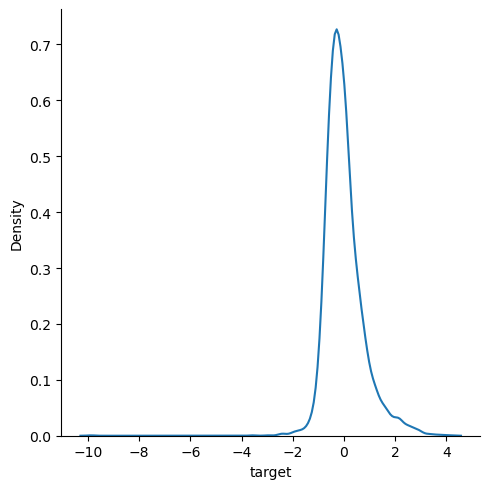

In [42]:
import seaborn as sns
sns.displot(y_test-pred,kind='kde')

In [43]:
from sklearn.metrics import r2_score

r2_score(y_test,pred)

0.5758157428913682

In [44]:
# Lasso
from sklearn.linear_model import Lasso

In [45]:
lasso = Lasso()

In [79]:
parameter_variable = {'alpha':[2,5,10,20,14,30,50,60,12,80,90,1,45,127,0.1,12,89,0.01]}

lassocv = GridSearchCV(lasso,parameter_variable,scoring='neg_mean_squared_error',cv=10)
lassocv.fit(X_train,y_train)


GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [2, 5, 10, 20, 14, 30, 50, 60, 12, 80, 90, 1,
                                   45, 127, 0.1, 12, 89, 0.01]},
             scoring='neg_mean_squared_error')

In [80]:
print(lassocv.best_params_)

{'alpha': 0.01}


In [81]:
print(lassocv.best_score_)

-0.5245802102915532


In [82]:
lasso_pred = lassocv.predict(X_test)
lasso_pred

array([0.78787312, 1.73253525, 2.5649099 , ..., 4.40562063, 1.2930991 ,
       1.95300562])

In [83]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

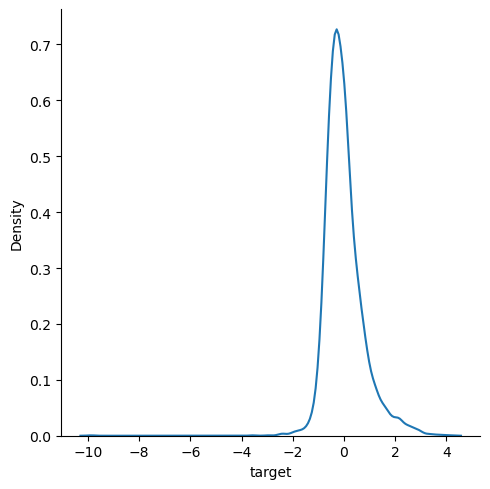

In [77]:
sns.displot(y_test-lasso_pred,kind='kde')

In [84]:
r2_score(y_test,lasso_pred)

0.5816154300698727